# Implémentation de l'algorithme DMRG (one site DMRG)

In [201]:
import numpy as np
import scipy as sc
import copy
import matplotlib.pyplot as plt

### Initialisation du MPS:

On initialise l'algorithme en tirant un MPS formé de N tenseurs aléatoires avec d le nombres de paramètre physiques et chi la bond dimension du MPS).
Le premier tenseur (extrémité gauche) est de taille (d,chi), les 
tenseurs centraux sont de taille (chi,d,chi), le dernier tenseur (extrémité droite) est de taille (chi,d) (voir schéma)

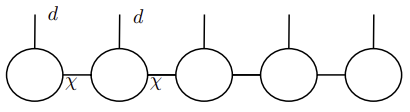

In [204]:
# Initialisation:


def initialization(N,d,chi):
    """
    Input: N longueur du MPS, d dimension physique, chi bond dimension
    Output: MPS aléatoire de longueur N, de dimension physique d, bond dimension chi
    """
    np.random.seed(2)  # Set a fixed seed for NumPy
    A = [] # liste contenant le MPS 

    #Convention: on numérote initialement les tenseurs dans le sens anti trigo, en partant de la branche à gauche

    #Ajout du premier tenseur (rang 2)
    A.append(np.random.rand(d,chi))

    #Ajout des tenseurs "centraux" (rang 3)
    for _ in range(N-2):
        A.append(np.random.rand(chi,d,chi))

    #Ajout du dernier tenseur (rang 2)
    A.append(np.random.rand(chi,d))

    return A

## Codage de l'opérateur sous la forme d'un MPO

Afin de pouvoir appliquer un opérateur au MPS, il va falloir le représenter sous la forme d'un MPO. De la même manière que pour les MPS, les MPO seront représentés comme une liste d'array numpy. 

Les tenseurs ont les tailles suivantes:
 - $(\chi,d,\chi)$ pour le premier tenseur (extrémité gauche)
 - $(\chi,d,\chi,d)$ pour les tenseurs centraux
 - $(d,\chi,\chi)$ pour le dernier tenseur (extrémité droite)

**Remarque:** La bond dimension du MPO notée $\chi$ est indépendante de la bond dimension du MPS, celles-ci peuvent très bien être différentes




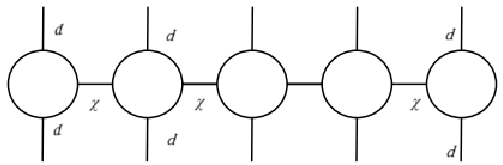

Le codage d'un opérateur sous sa forme MPO se fait de la manière suivante:

Nous allons d'abord écrire les fonctions qui permettent de décomposer un hamiltonien sous forme d'un MPO. Pour cela, nous considérerons un opérateur $\hat{H}$ qu'on suppose être une somme de produits d'opérateurs de Pauli.

Considérons par exemple le cas $N=4$ (4 sites)

Pour obtenir la forme $\hat{H} = \sum_{i} C_{i}\hat{S}_{1}\hat{S}_{2}\hat{S}_{3}\hat{S}_{4}$ (où $C_{i}$ est un coefficient complexe, $\hat{S}_{k}$ est un opérateur de Pauli associé au $k$-ième site) à partir de $\hat{H}$ quelconque, on utilise la décomposition de Jordan-Wigner qui nous donne le hamiltonien décomposé en somme de produits d'opérateurs de Pauli. Les MPO associés aux produits correspondent simplement aux produits des matrices de Pauli.

Enfin, pour obtenir la représentation MPO de $\hat{H}$, on additionnera successivement les représentations MPO des produits de matrices de Pauli.


Les matrices de Pauli sont les suivantes:

In [210]:
#Définition des matrices de Pauli
Sx=np.array([[0,1],[1,0]], dtype="complex_")
Sy=np.array([[0,-1j],[1j,0]], dtype="complex_")
Sz=np.array([[1,0],[0,-1]], dtype="complex_")
I2=np.array([[1,0],[0,1]], dtype="complex_")

In [212]:
Splus=0.5*(Sx+1j*Sy)
Sminus=0.5*(Sx-1j*Sy)

On encode ensuite les opérateurs de Pauli (à un site) sous la forme de tenseurs. Celle-ci correspond simplement à la matrice de Pauli associée (bond dimension $\chi=1$)

In [215]:
#Opérateur de Pauli Sx

#Tenseur central
Hx=np.zeros((1,2,1,2),dtype="complex_")
Hx[0,:,0,:]=Sx

#Premier tenseur (extrémité gauche)
Hxg=np.zeros((2,1,2),dtype="complex_")
Hxg[:,0,:]=Sx

#Dernier tenseur (extrémité droite)
Hxd=np.zeros((1,2,2),dtype="complex_")
Hxd[0,:,:]=Sx

In [217]:
#Opérateur de Pauli Sy

#Tenseur central
Hy=np.zeros((1,2,1,2),dtype="complex_")
Hy[0,:,0,:]=Sy

#Premier tenseur (extrémité gauche)
Hyg=np.zeros((2,1,2),dtype="complex_")
Hyg[:,0,:]=Sy

#Dernier tenseur (extrémité droite)
Hyd=np.zeros((1,2,2),dtype="complex_")
Hyd[0,:,:]=Sy

In [219]:
#Opérateur de Pauli Sz

#Tenseur central
Hz=np.zeros((1,2,1,2), dtype="complex_")
Hz[0,:,0,:]=Sz

#Premier tenseur (extrémité gauche)
Hzg=np.zeros((2,1,2),dtype="complex_")
Hzg[:,0,:]=Sz

#Dernier tenseur (extrémité droite)
Hzd=np.zeros((1,2,2),dtype="complex_")
Hzd[0,:,:]=Sz

In [221]:
#Opérateur identité

#Tenseur central
H2=np.zeros((1,2,1,2),dtype="complex_")
H2[0,:,0,:]=I2

#Premier tenseur (extrémité gauche)
H2g=np.zeros((2,1,2),dtype="complex_")
H2g[:,0,:]=I2

#Dernier tenseur (extrémité droite)
H2d=np.zeros((1,2,2),dtype="complex_")
H2d[0,:,:]=I2

In [223]:
#Opérateur de Pauli Splus

#Tenseur central
Hplus=np.zeros((1,2,1,2),dtype="complex_")
Hplus[0,:,0,:]=Splus

#Premier tenseur (extrémité gauche)
Hplusg=np.zeros((2,1,2),dtype="complex_")
Hplusg[:,0,:]=Splus

#Dernier tenseur (extrémité droite)
Hplusd=np.zeros((1,2,2),dtype="complex_")
Hplusd[0,:,:]=Splus

In [225]:
#Opérateur de Pauli Sminus

#Tenseur central
Hminus=np.zeros((1,2,1,2),dtype="complex_")
Hminus[0,:,0,:]=Sminus

#Premier tenseur (extrémité gauche)
Hminusg=np.zeros((2,1,2),dtype="complex_")
Hminusg[:,0,:]=Sminus

#Dernier tenseur (extrémité droite)
Hminusd=np.zeros((1,2,2),dtype="complex_")
Hminusd[0,:,:]=Sminus

### Somme de deux MPO

In [228]:

# prend deux MPO A et B en entrée (de même longueur) et renvoie le MPO correspondant à la somme de A et B
# Rq: les MPO sont supposés du même format que précedemment

def MPO_sum(A,B):
    """
    Input: A,B deux MPO de même longueur n (listes d'arrays correspondant aux tenseurs du MPO) 
    Sortie: renvoie le MPO A+B (de longueur n) (liste d'arrays)

    """
    n = len(A)
    chi_A = A[0].shape[1]
    chi_B = B[0].shape[1]
    chi_S = chi_A + chi_B
    S = []
    d = A[0].shape[0]

    #Ajout du premier tenseur
    S_i = np.zeros((d,chi_S,d), dtype="complex_")
    for sigma1 in range(d):
        for sigma2 in range(d):

            for k in range(chi_A):
                S_i[sigma1,k,sigma2] = A[0][sigma1,k,sigma2]

            for k in range(chi_B):
                S_i[sigma1,k+chi_A,sigma2] = B[0][sigma1,k,sigma2]
            
    S.append(S_i)

    #Ajout des tenseurs "centraux"
    for i in range(1,n-1):
        S_i = np.zeros((chi_S,d,chi_S,d), dtype="complex_")
        for sigma1 in range(d):
            for sigma2 in range(d):
                
                for k in range(chi_A):
                    for l in range(chi_A):
            
                        S_i[k,sigma1,l,sigma2] = A[i][k,sigma1,l,sigma2]

                for k in range(chi_B):
                    for l in range(chi_B):
                        S_i[chi_A + k,sigma1,chi_A + l,sigma2] = B[i][k,sigma1,l,sigma2]      
        S.append(S_i)

    #Ajout du dernier tenseur
    S_i = np.zeros((chi_S,d,d), dtype="complex_")
    for sigma1 in range(d):
        for sigma2 in range(d):

            for k in range(chi_A):
                S_i[k,sigma1,sigma2] = A[n-1][k,sigma1,sigma2]

            for k in range(chi_B):
                S_i[k+chi_A,sigma1,sigma2] = B[n-1][k,sigma1,sigma2]
    S.append(S_i)
    
    
    return S


In [230]:
def pauli_to_MPO(H): #H est un hamiltonien donné sous forme d'une somme de produits de tenseurs de Pauli. Ici H est représenté sous forme de tableau où les termes en d'indice i dans la somme sont à la ième ligne
    """
    Input: H hamiltonien (somme de produits d'opérateurs de Pauli) sous la forme d'un tableau dont la i-ème ligne contient les termes du i-ème produit de la somme
    Output: renvoie le MPO M associé à H (liste d'arrays)

    On calcule le MPO associée somme des produits de Pauli pour obtenir la représentation MPO de H
    """
    M=H[0]
    for i in range(len(H)-1):
        M=MPO_sum(M,H[i+1])
    return M

In [232]:

def hamiltonien(nb, liste,d):
    """
    Prend en entrée le nombre de sites de bain nb (ce qui nous donne N par N=2(nb+1))
    et la liste des opérateurs de spins / site où il agissent par l'algorithme de Jordan-Wigner
    (fonction parse_hamiltonien du groupe quantique)
    """
    
    
    N=2*(nb+1)
    l=len(liste)
    "Initialisation de H par l'identité"
    H=[[H2 for i in range(N)] for j in range(l-2)]
    for j in range(l-2):
        H[j][0]=H2g
        H[j][-1]=H2d
    "On remplace l'identité par les opérateurs de spin et les coefficients complexes aux positions adéquates"
    "Coeff de I^N"
    H[0][0]=liste[1]*H2g
    "Les autres coeffs et opérateurs de spin"
    for j in range(1,l-2):
        for i in range(len(liste[j+2][0])):
            if liste[j+2][2][i]=='X':
                "k donne le site du MPS sur lequel l'opérateur doit s'appliquer"
                k=liste[j+2][0][i]
                if k==0:
                    H[j][k]=Hxg
                elif k==(N-1):
                    H[j][k]=Hxd
                else:
                    H[j][k]=Hx
            elif liste[j+2][2][i]=='Y':
                k=liste[j+2][0][i]
                if k==0:
                    H[j][k]=Hyg
                elif k==(N-1):
                    H[j][k]=Hyd
                else:
                    H[j][k]=Hy
            else:
                k=liste[j+2][0][i]
                if k==0:
                    H[j][k]=Hzg
                elif k==(N-1):
                    H[j][k]=Hzd
                else:
                    H[j][k]=Hz
        H[j][0]=liste[j+2][1]*H[j][0]

    "H est maintenant sous la bonne forme pour qu'on puisse lui appliquer pauli_to_MPO"
    H=pauli_to_MPO(H)
    return(H)


Grâce à la décomposition de Jordan-Wigner, on obtient la décomposition suivante pour le hamiltonien d'Anderson à 4 sites

In [235]:

H0 = [[0.25*H2g,H2,H2,H2d],
            [0.25*Hzg,Hz,H2,H2d],
            [0.25*Hzg,H2,H2,H2d],
            [0.25*H2g,Hz,H2,H2d],
            [0.5*Hxg,Hz,Hx,H2d],
            [0.5*Hyg,Hz,Hy,H2d],
            [0.5*H2g,Hx,Hz,Hxd],
            [0.5*H2g,Hy,Hz,Hyd],
            [-0.5*H2g,H2,Hz,H2d],
            [-0.5*H2g,H2,H2,Hzd]]


In [237]:
H=pauli_to_MPO(H0)
print(len(H))

4


In [239]:
Hh=hamiltonien(1, [[range(0, 4)], 0.25, 'I^4', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.5+0j), 'XZX'), ([0, 1, 2], (0.5+0j), 'YZY'), ([1, 2, 3], (0.5+0j), 'XZX'), ([1, 2, 3], (0.5+0j), 'YZY'), ([2], (-0.5+0j), 'Z'), ([3], (-0.5+0j), 'Z')],2)

In [241]:
Hid=[H2g,H2,H2,H2d]


## Orthonormalisation du MPS

Dans cette partie, on va définir les fonctions permettant d'orthonormaliser (à droite ou à gauche) le MPS. En effet, l'algorithme DMRG nécessite de manipuler des MPS vérifiant certaines propriétés d'orthogonalité à droite ou à gauche (cf. rapport)

Le procédé d'orthonormalisation s'effectue par décompositions QR (ou RQ selon le cas) successives sur les tenseurs du MPS. La procédure complète est expliquée avec plus de détails dans le rapport 

**Remarque**: Les bond dimensions des tenseurs du MPS orthonormalisé restent inférieures ou égales à $\chi$

In [247]:

def MPS_orth_left(A): #Normalise le MPS à gauche en effectuant des décompositions QR successives
    """
    Input: MPS A de longueur N (liste de N arrays)
    Output: MPS M correspondant à la forme orthonormalisée à gauche de A (liste de N arrays)
    """
    M = copy.deepcopy(A)
    N = len(M)
    chi = A[0].shape[1]
    d = A[0].shape[0]

    #Traitement du premier tenseur
    q,r = sc.linalg.qr(M[0], mode = "economic") #décomposition QR du premier tenseur
    M[0] = q # M[0] <- q
    M[1] = np.tensordot(r,M[1], axes = ([1],[0])) #On contracte r au tenseur suivant (2nd tenseur) afin de réitérer la procédure

    
    #Traitement des tenseurs centraux
    for i in range(1,N-1): #On ne s'occupe pas du dernier tenseur
        p=np.shape(M[i])[0] # correspond à la bond dimension à gauche du i-ème tenseur
        M[i] = np.reshape(M[i],(d*p,chi)) #reshape du i-ème tenseur afin de pouvoir appliquer la décomposition QR
        q,r = sc.linalg.qr(M[i], mode = "economic") # décomposition QR
        M[i] = np.reshape(q,(np.shape(q)[0]//d,d,np.shape(q)[1])) # M[i] <- q (après reshape de q afin d'obtenir un tenseur de rang 3)
        M[i+1] = np.tensordot(r,M[i+1], axes = ([1],[0])) #on contracte r au tenseur suivant afin de réitérer la procédure


    return M

#L'orthonormalisation à droite s'effectue de la même manière en balayant de droite à gauche, et en effectuant une décomposition RQ (au lieu de QR)
def MPS_orth_right(A):
    """
    Input: MPS A de longueur N (liste de N arrays)
    Output: MPS M correspondant à la forme orthonormalisée à droite de A (liste de N arrays)
    """

    M = copy.deepcopy(A)
    N = len(M)
    chi = A[N-1].shape[0]
    d = A[0].shape[0]
    
    r,q = sc.linalg.rq(M[N-1],mode = "economic")
    M[N-1]=q
    M[N-2] = np.tensordot(M[N-2],r,axes = ([2],[0]))
    

    for i in range(N-2,0,-1): #On ne s'occupe pas du premier tenseur
        chi = A[i].shape[0]
        M[i]=np.reshape(M[i],(chi,d*np.shape(M[i])[2]))
        r,q = sc.linalg.rq(M[i], mode = "economic")
        M[i] = np.reshape(q,(np.shape(q)[0],d,np.shape(q)[1]//d))
        M[i-1] = np.tensordot(M[i-1],r,1)

    
    return M

In [249]:
def test_norm_right(A,N):
    T = np.tensordot(A[N-1],A[N-1].conj().T, axes = ([1],[0]))
    print(A[N-4].shape)
    print(A[N-4].conj().T.shape)
    T_aux =  np.tensordot(A[N-4],A[N-4].conj().T, axes = ([0],[1]))

    print(T_aux)

**Remarque:** En pratique, on n'utilisera que l'orthonormalisation à droite dans la mise en pratique de l'algorithme.

## Opérations de contractions et tenseurs auxiliaires

Dans cette partie, nous définirons les tenseurs auxiliaires et les fonctions de contractions utilisés dans l'algorithme. Ils serviront au calcul de l'opérateur à diagonaliser lors de l'exécution de l'algorithme.

Une des étapes de l'algorithme DMRG consiste en effet à diagonaliser le tenseur suivant (où i varie entre $0$ et $N-1$) 



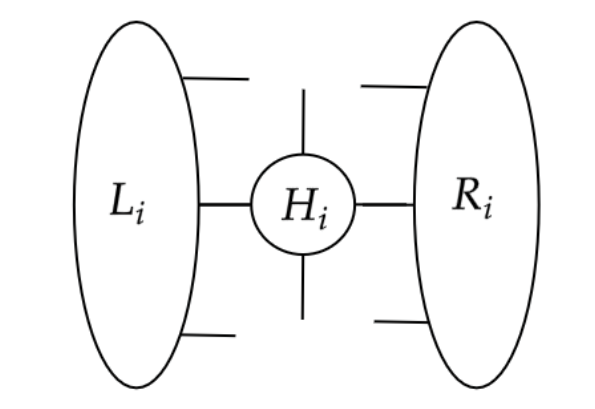

(où $L_i$ correspond à la contraction des tenseurs $M_k$, $H_k$, $M^{\dagger}_k$ pour $k<i$ et $R_i$ correspond à la contraction des tenseurs $M_k$, $H_k$, $M^{\dagger}_k$ pour $k>i$

Les fonctions suivantes permettent de calculer successivement les tenseurs $L_i$ et $R_i$ à partir du MPS et du MPO. 

**Remarque:** Pour les indices i=0 (resp. N-1) aux extrémités, on ne considère que $R_i$ (resp $L_i$)  

Les entrées de la fonction right_contraction sont les tenseurs décrits par le schéma suivant.

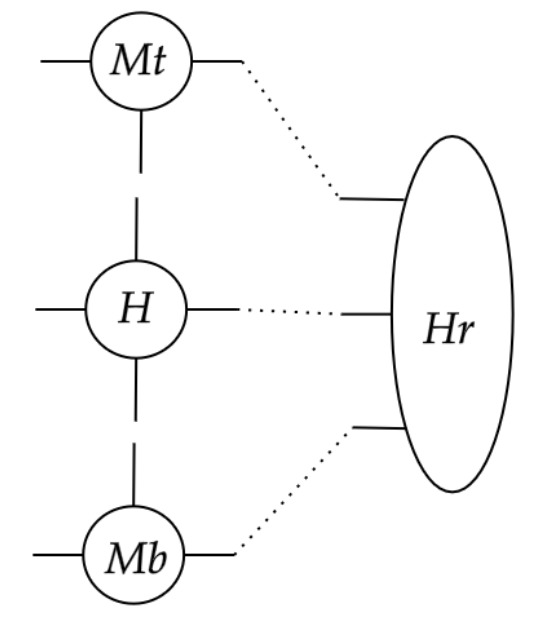

De même, la fonction left_contraction est décrite par le schéma ci-dessous

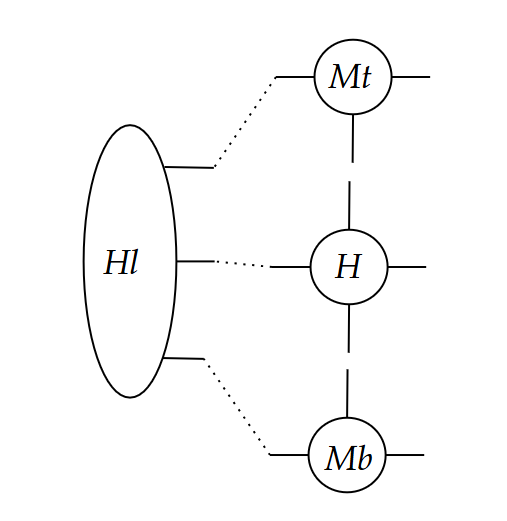

In [258]:

def right_contraction(Hr, Mt, Mb, H):
    """
    Input: tenseurs Hr, Mt, Mb, H (voir premier schéma)
    Output: renvoie le tenseur résultant de la contraction de ces quatres tenseurs (voir schéma)
    """
    Taux = np.tensordot(Hr,Mb, axes = ([2],[2]))
    Taux = np.tensordot(Taux,H, axes = ([3,0],[3,2]))
    Taux = np.tensordot(Taux,Mt, axes = ([0,3],[0,1]))
    Taux = np.transpose(Taux,(1,2,0))  #ordre final: de bas en haut: 2,0,1 (sens horaire en partant du milieu)

    return Taux

def left_contraction(Hl,Mt,Mb,H):
    """
    Input: tenseurs Hl, Mt, Mb, H (voir schéma ci-dessus)
    Output: renvoie le tenseur résultant de la contraction de ces quatres tenseurs (voir schéma)
    """

    Taux = np.tensordot(Hl,Mb, axes = ([2],[0]))
    Taux = np.tensordot(Taux,H, axes = ([1,2],[0,3]))
    Taux = np.tensordot(Taux,Mt, axes = ([0,2],[2,1]))
    Taux = np.transpose(Taux,(2,1,0)) #ordre final: de haut en bas: 0, 1, 2

    return Taux


**Remarque:** Dans l'algorithme, on appellera la fonction avec les arguments $Mt = M^\dagger_k$, $Mb = M_k$, $Hr = R_k$

Au cours de l'algorithme, il est utile de garder ces tenseurs en mémoire: on va les stocker dans les listes R et L (qui seront ensuite mise à jour au fil des balayages). Afin de procéder au premier balayage, on va calculer R. Pour cela, on commence par calculer R[N-2] (extrémité droite), puis on calcule successivement R[N-3],...,R[0] grâce à la fonction right_contraction définie précedemment. 

A partir des tenseurs $L_i$ ,$R_i$ et $H_i$ on peut ensuite assembler le tenseur à diagonaliser, puis à le réindexer pour obtenir une matrice qui pourra être diagonalisée.

In [263]:
def effective_Matrix(L,R,H): #Calcule la matrice effective à diagonaliser
        """
        Input: tenseur L,R,H décrit par les schémas précédents
        Output: renvoie la matrice effective à diagonaliser ainsi qu'un tuple gardant en mémoire la forme du tenseur
        """
        #On calcule d'abord le tenseur à diagonaliser en contractant L,R et H
        Meff = np.tensordot(L,H,axes = ([1],[0]))
        Meff = np.tensordot(Meff,R, axes = ([3],[0]))
        Meff = np.transpose(Meff, (0,2,4,1,3,5))

        #On reshape ce tenseur afin d'obtenir une matrice
        t=np.shape(Meff)
        Meff = np.reshape(Meff,(t[0]*t[1]*t[2],t[3]*t[4]*t[5]))
        return Meff,t    

In [265]:
def valeur_moyenne(H,A):
    """
    Input: MPO H, MPS A
    Output: renvoie la valeur moyenne de H pour l'état M
    """
    N = len(H)
    M = copy.deepcopy(A)
    
    Taux = np.tensordot(H[N-1],M[N-1], axes = ([2],[1]))
    Taux = np.tensordot(Taux,M[N-1].conj().T, axes = ([1],[0]))
    Raux = np.transpose(Taux,(0,2,1))

    for i in range(N-3,-1,-1):
        Raux = right_contraction(Raux,M[i+1].conj().T,M[i+1],H[i+1])

    Taux = np.tensordot(H[0],M[0], axes = ([2],[0]))
    Taux = np.tensordot(Taux,M[0].conj().T, axes = ([0],[1]))
    Taux = np.transpose(Taux,(2,0,1))

    Res = np.tensordot(Taux,Raux, axes = ([0,1,2],[1,0,2]))
    return Res

    

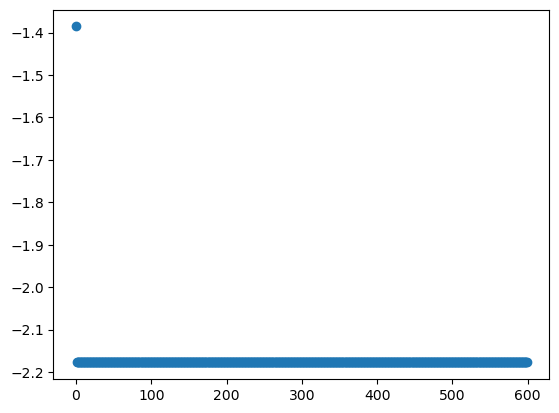

In [267]:
def DMRG(Np,N,d,chi,H):
    """
    Input: nombre de balayages (aller-retour) Np, paramètres du système N, d, chi, H hamiltonien sous forme de MPO
    Output: liste contenant les valeurs approchées de l'énergie la plus basse, MPS final
    """
    E = [] #liste des énergies
    
    #Création d'un MPS A orthonormalisé à droite
    A = initialization(N,d,chi)
    A = MPS_orth_right(A)

    
    R = [0 for _ in range(N)] #liste contenant les R_i
    L = [0 for _ in range(N)] #liste contenant les L_i
    
    #Calcul de R[N-2] par contraction de H[N-1], A[N-1] et son transconjugué
    Taux1 = np.tensordot(H[N-1],A[N-1], axes = ([2],[1]))
    
    Taux1 = np.tensordot(Taux1,A[N-1].conj().T, axes = ([1],[0]))
    R[N-2] = np.transpose(Taux1,(0,2,1))

    #Calcul des R[i]
    for i in range(N-3,-1,-1):
        R[i] = right_contraction(R[i+1],A[i+1].conj().T,A[i+1],H[i+1])

    #Balayages
    for _ in range(Np):
       
        #Balayage de gauche à droite
       
        #Traitement du 1er tenseur (cas de bord: les dimensions de A[0] sont différentes)

        Meff = np.tensordot(H[0],R[0],axes = ([1],[0]))
        Meff = np.transpose(Meff, (0,2,1,3))
        t=np.shape(Meff)
        Meff = np.reshape(Meff, (t[0]*t[1],t[2]*t[3]))
        
        # Diagonalisation (Lanczos)
        #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[0]) 
        eigenvalues,eigenvec = np.linalg.eigh(Meff)
        val = eigenvalues[0]
        vec = eigenvec[:,0] 
        vec = vec/ np.linalg.norm(vec)
        vec = np.reshape(vec,(t[2],t[3]))
        #E.append("gauche")
        E.append(val)
        

        #Décomposition SVD sur la matrice obtenue
        U,s,V = sc.linalg.svd(vec,full_matrices = False)
        S = np.diag(s)
        V = np.matmul(S,V)

        # Mise à jour des tenseurs A[0] et A[1]
        
        A[0] = U.copy()
        A[1] = np.tensordot(V,A[1],1)

        #Calcul de L[1] 

        Taux2 = np.tensordot(H[0],A[0], axes = ([2],[0]))
        Taux2 = np.tensordot(Taux2,A[0].conj().T, axes = ([0],[1]))
        L[1] = np.transpose(Taux2,(2,0,1))

        #print(valeur_moyenne(H,A))
        

        
        
        for i in range(1,N-1): #balayage de gauche à droite (pour les tenseurs centraux)
            Meff,t = effective_Matrix(L[i],R[i],H[i])
            
            # Diagonalisation (Lanczos)
            #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[i])
            eigenvalues,eigenvec = np.linalg.eigh(Meff)
            val = eigenvalues[0]
            vec = eigenvec[:,0] 
            vec = vec/ np.linalg.norm(vec)
            vec = np.reshape(vec,(t[3]*t[4],t[5]))
            E.append(val)

            #Décomposition SVD sur la matrice obtenue
            U,s,V = sc.linalg.svd(vec,full_matrices = False)
            S = np.diag(s)
            V = np.matmul(S,V)

            # Mise à jour des tenseurs A[i] et A[i+1]
            A[i] = np.reshape(U,(t[3],t[4],np.shape(U)[1]))
            A[i+1] = np.tensordot(V,A[i+1],1)

            #Calcul de L[i] 
            L[i+1] = left_contraction(L[i],A[i].conj().T,A[i],H[i])

        

        #Traitement du dernier tenseur


        #Balayage de droite à gauche
        
        #Traitement du dernier tenseur
        
        Meff = np.tensordot(L[N-1],H[N-1],axes = ([1],[0]))
        Meff = np.transpose(Meff, (0,2,1,3))
        t=np.shape(Meff)
        Meff = np.reshape(Meff, (t[0]*t[1],t[2]*t[3]))

    

        # Diagonalisation (Lanczos)
        #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[N-1]) 
        eigenvalues, eigenvec = np.linalg.eigh(Meff)
        val = eigenvalues[0]
        vec = eigenvec[:,0] 
        vec = vec/ np.linalg.norm(vec)
        vec = np.reshape(vec,(t[2],t[3]))
        #E.append("droite")
        E.append(val)

        # Décomposition SVD sur la matrice obtenue
        U,s,V = sc.linalg.svd(vec,full_matrices = False)
        S = np.diag(s)
        U = np.matmul(U,S)

        # Mise à jour des tenseurs A[N-1] et A[N-2]
        
        A[N-1] = V
        A[N-2] = np.tensordot(A[N-2],U,1)
    

        #Calcul de R[N-2] 
        Taux3 = np.tensordot(H[N-1],A[N-1], axes = ([2],[1]))
        Taux3 = np.tensordot(Taux3,A[N-1].conj().T, axes = ([1],[0]))
        R[N-2] = np.transpose(Taux3,(0,2,1))

        #print(valeur_moyenne(H,A))

        

        for i in range(N-2,0,-1): #balayage de droite à gauche (pour les MPS centraux)
    
            Meff,t = effective_Matrix(L[i],R[i],H[i])
            

            # Diagonalisation (Lanczos)
            #val,vec = sc.sparse.linalg.eigsh(Meff, k=1, which='SA', v0=A[i]) 
            eigenvalues,eigenvec = np.linalg.eigh(Meff)
            val = eigenvalues[0]
            vec = eigenvec[:,0]
            vec = vec/ np.linalg.norm(vec)
            vec = np.reshape(vec,(t[3],t[4]*t[5]))
            E.append(val)
            #E.append(val[0])

            #Décomposition SVD sur la matrice obtenue
            U,s,V = sc.linalg.svd(vec,full_matrices = False)
            S = np.diag(s)
            U = np.matmul(U,S)
        
            # Mise à jour des tenseurs A[i] et A[i+1]
        
            A[i] = np.reshape(V,(np.shape(V)[0],t[4],t[5]))
            A[i-1] = np.tensordot(A[i-1],U,1)

            #Calcul de R[i-1] 
            R[i-1] = right_contraction(R[i],A[i].conj().T,A[i],H[i])
            #print(valeur_moyenne(H,A))
        
        

        #print(valeur_moyenne(copy.deepcopy(H),copy.deepcopy(A)))
        
    return E,A

energies, Mf = DMRG(100,4,2,5,H)


indices = list(range(len(energies)))

# Tracé du graphique avec l'index en abscisse
plt.plot(indices, energies, marker = "o",linestyle = "none")



# Afficher le graphique
plt.show()

        

## Calcul des fonctions de Green

On définit ci-dessous des fonctions permettant de manipuler les MPS et MPO. 


La fonction overlap permet de calculer le produit scalaire entre deux MPS

In [272]:
def overlap(M1,M2):
    """
    Input: MPS M1, MPS M2 of same length
    Output:overlap of M1 and M2 <M1|M2>
    """
    n = len(M1)
    overlap = np.tensordot(M1[0].conj().T,M2[0],axes = ([1],[0]))
    for i in range(1,n-1):
        overlap = np.tensordot(overlap,M2[i],axes = ([1],[0]))
        overlap = np.tensordot(M1[i].conj().T,overlap, axes = ([2,1],[0,1]))
    overlap = np.tensordot(overlap,M2[n-1],axes = ([1],[0]))
    overlap = np.tensordot(overlap,M1[n-1].conj().T,axes = ([1,0],[0,1]))
    return overlap



In [274]:
print(overlap(Mf,Mf)) # L'état de plus basse énergie calculé par DMRG est bien normalisé

(1.0000000000000002+0j)


La fonction ci-dessous permet d'appliquer un opérateur H sous forme de MPO à un MPS M. L'opération se fait de manière naïve, ce qui fait que la dimension de liaison du MPS en sortie est égale au produit des dimensions de liaison du MPO et du MPS en entrée.

In [277]:
def applyMPOtoMPS(H,M):
    """
    Input: MPO H, MPS M de même longueur
    Output: MPS correspondant au produit P = HM

    Remarque: On effectue le produit en contractant de manière naïve, ce qui fait que la bond dimension du MPS sortant est égale 
    au produit des bond dimensions du MPO et du MPS en entrée
    """
    N = len(M)
    P = [] #MPS correspondant au produit
    
    #Traitement du premier tenseur
    
    T = np.tensordot(H[0],M[0], axes = ([2],[0]))
    T = np.reshape(T,(H[0].shape[0],H[0].shape[1]*M[0].shape[1]))
    P.append(T)

    #Traitement des tenseurs centraux

    for i in range(1,N-1):
        T = np.tensordot(H[i],M[i], axes = ([3],[1]))
        T = np.transpose(T,(0,3,1,2,4))
        T = np.reshape(T,(H[i].shape[0]*M[i].shape[0],H[i].shape[1],H[i].shape[2]*M[i].shape[2]))

        P.append(T)

    #Traitement du dernier tenseur

    T = np.tensordot(H[N-1],M[N-1], axes = ([2],[1]))
    T = np.transpose(T,(0,2,1))
    T = np.reshape(T,(H[N-1].shape[0]*M[N-1].shape[0],H[N-1].shape[1]))
    P.append(T)

    return P


Pour contrôler la croissance de la dimension de liaison, il est donc nécessaire de compresser les MPS après opérations. On code ici une fonction de compression qui prend en entrée un MPS M et une dimension de liaison $\chi$ maximale. La fonction procède alors à la compression de la manière suivante: on commence d'abord par normaliser à droite le MPS. Puis, on applique SVD de droite à gauche, en ne conservant que $\chi$ valeurs singulières.

**Remarque:** La normalisation permet de compresser le MPS en conservant un contrôle sur l'erreur de troncation. En compressant de la sorte, on peut montrer que l'erreur vaut: $\epsilon_{\text{trunc}} = \sum_{i > \chi} \lambda_i^2$, les $\lambda_i$ étant les valeurs singulières.

In [280]:
def compressionSVD(M,chi):
    """
    Input: MPS M, bond dimension maximale chi
    Output: MPS A obtenu en compressant M par SVD successifs
    """
    n = len(M)
    A = MPS_orth_right(M)
    
    
    #Traitement du premier tenseur
    U,s,V = sc.linalg.svd(A[0],full_matrices = False)
    S = np.diag(s)

    #Compression
    if A[0].shape[1] > chi:
        U= U[:, :chi]
        S= np.diag(s[:chi])
        V= V[:chi, :]


    
    V = np.matmul(S,V)
    A[0] = U.copy()
    A[1] = np.tensordot(V,A[1],1)
    
    #Traitement des tenseurs centraux
    for i in range(1,n-1):
        t = A[i].shape

        A[i] = np.reshape(A[i],(A[i].shape[0]*A[i].shape[1],A[i].shape[2]))
        U,s,V = sc.linalg.svd(A[i],full_matrices = False)
        S = np.diag(s)
        if t[2] > chi:
            U= U[:, :chi]
            S= np.diag(s[:chi])
            V= V[:chi, :]
        
        V = np.matmul(S,V)
        
        # Mise à jour des tenseurs A[i] et A[i+1]
        A[i] = np.reshape(U,(t[0],t[1],U.shape[1]))
        A[i+1] = np.tensordot(V,A[i+1],1)


    return A


L'objectif est de calculer la fonction de Green $G^{>}(t) = \bra{\Psi_0} e^{iHt} c  e^{-iHt} c^{\dagger} \ket{\Psi_0} = e^{iE_0 t} \bra{\Psi_0} c  e^{-iHt} c^{\dagger} \ket{\Psi_0} = \bra{\Psi_1} e^{-iHt} \ket{\Psi_1} $ avec $\ket{\Psi_1} = c^{\dagger} \ket{\Psi_0}$

- Calculer $\ket{\Psi_0}$ par DMRG
- Calculer $\ket{\Psi_1}$ par contraction MPS-MPO. Rq: $c$ se décompose comme un produit tensoriel d'opérateurs sur chaque site, donc la contraction MPS et MPO est très simple
- Calculer $e^{-iHt}\ket{\Psi_1}$


Idée: $e^{-iHt} = e^{\frac{-iHt}{N}N} = (1-iH\delta t+o(\delta t^2))^N$ avec $\delta t = \frac{t}{N}$ puis appliquer $N$ fois (récursivement) le MPO $Id - iH\delta t$ au MPS $\ket{\Psi_1}$.

On peut alors calculer $G^{>}(t)=\bra{\Psi_1} e^{-iHt} \ket{\Psi_1}$ ainsi que $G^{<}(t)$ de la même manière. Grâce à cela, on peut ensuite calculer la fonction de Green retardée $G^{R}(t)$, puis l'échantillonner et effectuer une transformée de Fourier sur le signal obtenu afin de trouver la fonction spectrale $A(\omega)$
 



Voici la fonction permettant de calculer l'opérateur d'évolution en temps grâce à l'approximation décrite précedemment.

In [284]:
def timeEvolution(Npower,t,M,H,chi):
    """
    Input: int Npower (>0), float t, MPS M, MPO H hamiltonien du système
    Sortie: renvoie l'approximation du produit exp(-iH*t) M 
    """
    Hid = [H2g]
    for _ in range(len(H)-2):
        Hid.append(H2)
    Hid.append(H2d)
    
    
    #Calcul du développement de Taylor de l'exponentielle Heff
    delta_t = t/Npower
    Haux = copy.deepcopy(H)

    Haux[0]*=-1j*delta_t
    Heff = MPO_sum(Hid,Haux)

    #Multiplications successives par Heff
    res = M.copy()
    for _ in range(Npower):
        res = applyMPOtoMPS(Heff,res)
        res = compressionSVD(res,chi)

    return res
        


In [538]:
H0 = [[0.25*H2g,H2,H2,H2d], #1 site de bain, tous les paramètres égaux à 1
            [0.25*Hzg,Hz,H2,H2d],
            [0.25*Hzg,H2,H2,H2d],
            [0.25*H2g,Hz,H2,H2d],
            [0.5*Hxg,Hz,Hx,H2d],
            [0.5*Hyg,Hz,Hy,H2d],
            [0.5*H2g,Hx,Hz,Hxd],
            [0.5*H2g,Hy,Hz,Hyd],
            [-0.5*H2g,H2,Hz,H2d],
            [-0.5*H2g,H2,H2,Hzd]]

H3 = [[0.75*H2g,H2,H2,H2d],
            [0.25*Hzg,Hz,H2,H2d],
            [0.5*Hxg,Hz,Hx,H2d],
            [0.5*Hyg,Hz,Hy,H2d],
            [0.5*H2g,Hx,Hz,Hxd],
            [0.5*H2g,Hy,Hz,Hyd],
            [-0.5*H2g,H2,Hz,H2d],
            [-0.5*H2g,H2,H2,Hzd]]

H5 = [[-1.75*H2g,H2,H2,H2,H2,H2d],
            [0.25*Hzg,Hz,H2,H2,H2,H2d],
            [0.5*Hxg,Hz,Hx,H2,H2,H2d],
            [0.5*Hyg,Hz,Hy,H2,H2,H2d],
            [0.5*H2g,Hx,Hz,Hx,H2,H2d],
            [0.5*H2g,Hy,Hz,Hy,H2,H2d],
            [0.5*Hxg,Hz,Hz,Hz,Hx,H2d],
            [0.5*Hyg,Hz,Hz,Hz,Hy,H2d],
            [0.5*H2g,Hx,Hz,Hz,Hz,Hxd],
            [0.5*H2g,Hy,Hz,Hz,Hz,Hyd],
            [0.5*H2g,H2,Hz,H2,H2,H2d],
            [0.5*H2g,H2,H2,Hz,H2,H2d],
            [0.25*H2g,H2,H2,H2,Hz,H2d],
            [0.25*H2g,H2,H2,H2,H2,Hzd]
     ]

H4 = [[-0.25*H2g,H2,H2,H2,H2,H2d], #2 sites de bain , U = 1, mu = 0.5, eps = [-1,1], V = [1,1]
      [0.25*Hzg,Hz,H2,H2,H2,H2d],
      [0.5*Hxg,Hz,Hx,H2,H2,H2d],
      [0.5*Hyg,Hz,Hy,H2,H2,H2d],
            [0.5*H2g,Hx,Hz,Hx,H2,H2d],
            [0.5*H2g,Hy,Hz,Hy,H2,H2d],
            [0.5*Hxg,Hz,Hz,Hz,Hx,H2d],
            [0.5*Hyg,Hz,Hz,Hz,Hy,H2d],
            [0.5*H2g,Hx,Hz,Hz,Hz,Hxd],
            [0.5*H2g,Hy,Hz,Hz,Hz,Hyd],
            [0.5*H2g,H2,Hz,H2,H2,H2d],
            [0.5*H2g,H2,H2,Hz,H2,H2d],
            [-0.5*H2g,H2,H2,H2,Hz,H2d],
            [-0.5*H2g,H2,H2,H2,H2,Hzd]
     ]

In [572]:
def creation_op(Nsite,site):
    """
    Input: total number of sites, index of site
    Output: MPO of the creation op on site
    """
    op = []
    for i in range(Nsite):
        if i< site:
            if i==0:
                op.append(Hzg)
            else:
                op.append(Hz)
        elif i== site:
            if i==0:
                op.append(Hminusg)
            elif i == Nsite-1:
                op.append(Hminusd)
            else:
                op.append(Hminus)
        else:
            if i==0:
                op.append(H2g)
            elif i == Nsite-1:
                op.append(H2d)
            else:
                op.append(H2)
            
    return op
            
def annihilation_op(Nsite,site):
    """
    Input: total number of sites, index of site
    Output: MPO of the annihilation op on site
    """
    op = []
    for i in range(Nsite):
        if i< site:
            if i==0:
                op.append(Hzg)
            else:
                op.append(Hz)
        elif i== site:
            if i==0:
                op.append(Hplusg)
            elif i == Nsite-1:
                op.append(Hplusd)
            else:
                op.append(Hminus)
        else:
            if i==0:
                op.append(H2g)
            elif i == Nsite-1:
                op.append(H2d)
            else:
                op.append(H2)
    return op
    

In [590]:
H = pauli_to_MPO(H4)
n = len(H)
energies, Mf = DMRG(100,n,2,20,H)


In [592]:
#Définition des opérateurs création et annihilation 
c0_dagger = creation_op(n,0)
c0 = annihilation_op(n,0)


print(energies[-1])

-3.757254299416566


In [ ]:
from numpy.fft import ifft,ifftshift, fft, fftfreq, fftshift

E0  = energies[-1]
chi = 30
Npower = 10

t_max = 300
n_t = 5000

dt = t_max / n_t
eta = 0.1 # Damping



phi_add = applyMPOtoMPS(c0_dagger, Mf)  
phi_rem = applyMPOtoMPS(c0, Mf)         

phi_add = compressionSVD(phi_add, chi)
phi_rem = compressionSVD(phi_rem, chi)

T = dt
times = []
evolved_add = timeEvolution(Npower, dt, phi_add, H, chi)
evolved_rem = timeEvolution(Npower, -dt, phi_rem, H, chi)

G_t = []

for _ in range(n_t):
    print(f"Time: {T:.3f}")

    evolved_add = timeEvolution(Npower, dt, evolved_add, H, chi)
    evolved_rem = timeEvolution(Npower, -dt, evolved_rem, H, chi)
    T+=dt
    times.append(T)

    
    term_add = overlap(Mf, applyMPOtoMPS(c0, evolved_add))  
    term_rem = overlap(Mf, applyMPOtoMPS(c0_dagger, evolved_rem)) 

    G = -1j * (term_add*np.exp(1j*E0*T) + term_rem*np.exp(-1j*E0*T))
    G_t.append(G)

times = np.array(times)


G_t = np.array(G_t)
window = np.exp(-eta * times)
G_t_damped = G_t * window


G_omega = fftshift(fft(G_t_damped)) * dt
freqs = fftshift(fftfreq(n_t, d=dt)) * 2 * np.pi


A_omega = -np.imag(G_omega) / np.pi



Time: 0.060
Time: 0.120
Time: 0.180
Time: 0.240
Time: 0.300
Time: 0.360
Time: 0.420
Time: 0.480
Time: 0.540
Time: 0.600
Time: 0.660
Time: 0.720
Time: 0.780
Time: 0.840
Time: 0.900
Time: 0.960
Time: 1.020
Time: 1.080
Time: 1.140
Time: 1.200
Time: 1.260
Time: 1.320
Time: 1.380
Time: 1.440
Time: 1.500
Time: 1.560
Time: 1.620
Time: 1.680
Time: 1.740
Time: 1.800
Time: 1.860
Time: 1.920
Time: 1.980
Time: 2.040
Time: 2.100
Time: 2.160
Time: 2.220
Time: 2.280
Time: 2.340
Time: 2.400
Time: 2.460
Time: 2.520
Time: 2.580
Time: 2.640
Time: 2.700
Time: 2.760
Time: 2.820
Time: 2.880
Time: 2.940
Time: 3.000
Time: 3.060
Time: 3.120
Time: 3.180
Time: 3.240
Time: 3.300
Time: 3.360
Time: 3.420
Time: 3.480
Time: 3.540
Time: 3.600
Time: 3.660
Time: 3.720
Time: 3.780
Time: 3.840
Time: 3.900
Time: 3.960
Time: 4.020
Time: 4.080
Time: 4.140
Time: 4.200
Time: 4.260
Time: 4.320
Time: 4.380
Time: 4.440
Time: 4.500
Time: 4.560
Time: 4.620
Time: 4.680
Time: 4.740
Time: 4.800
Time: 4.860
Time: 4.920
Time: 4.980
Time

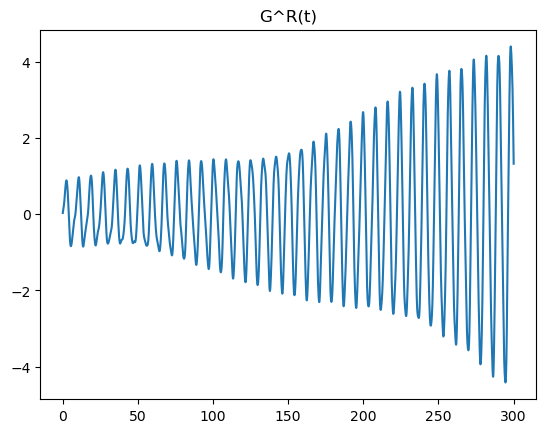

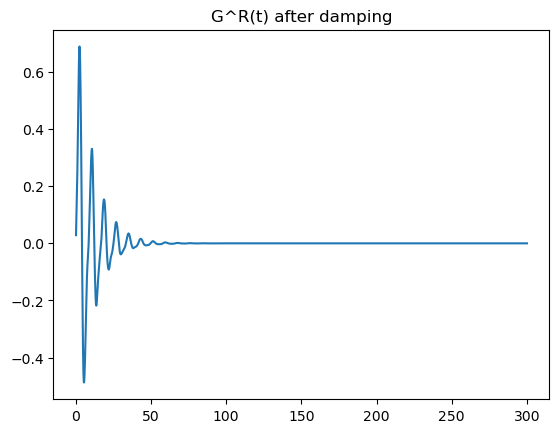

In [584]:
plt.plot(times,G_t)
plt.title("G^R(t)")
plt.show()

G1 = np.conj(G_t_damped) #On calcule ici  le conjugué A(omega) pour des raisons de convention de signe dans la transformée de Fourier

plt.plot(times,G1)
plt.title("G^R(t) after damping")
plt.show()

# Fourier transform
G_omega = fftshift(fft(G1)) * dt
freqs = (fftshift(fftfreq(n_t, d=dt)))  *2* np.pi 

# Spectral function
A_omega = np.imag(G_omega) / np.pi



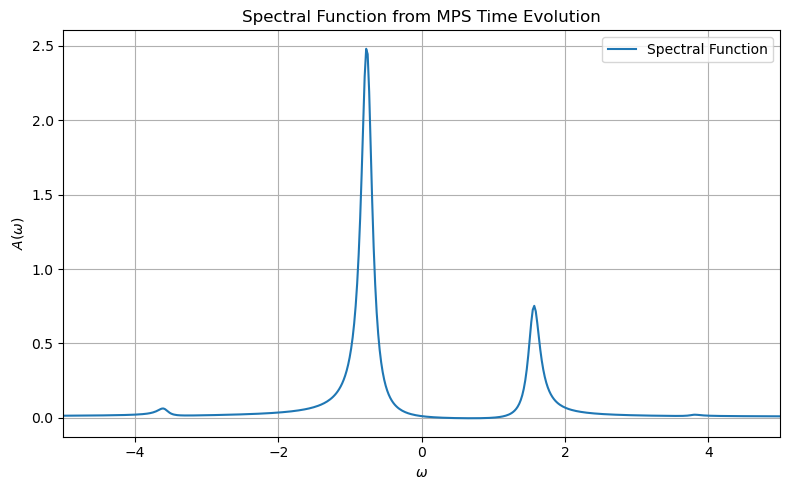

In [588]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(freqs, A_omega.real, label='Spectral Function')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$A(\omega)$')
plt.xlim(-5, 5)
plt.title('Spectral Function from MPS Time Evolution')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Influence de la dimension de liaison $\chi$

On rajoute H en paramètre du DMRG et on tente de passer de H sous forme Jordan-Wigner à H MPO

In [420]:
def variation_chi(Np,nb,d,H,chi_max):
    """
    Np, d, H comme dans DMRG
    On prend nb le nombre de sites de bain
    On fera varier chi de 1 à chi_max
    """
    chi=[i for i in range(1,chi_max+1)]
    e=[0 for i in range(1,chi_max+1)]
    for i in range(1,chi_max+1):
        E,A=DMRG(Np,2*(nb+1),d,i,H)
        e[i-1]=E[-1]
    return chi, e  

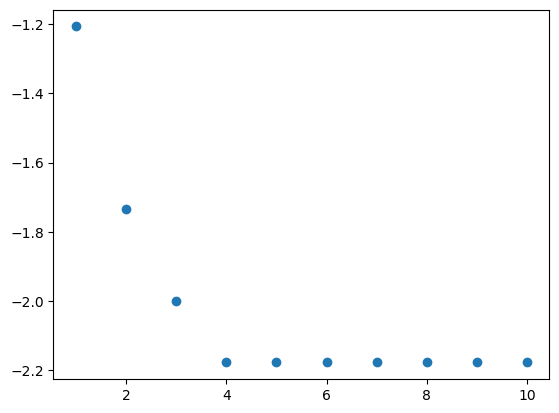

In [421]:
H=Hh
chi,e=variation_chi(10,1,2,Hh,10)

# Tracé du graphique avec chi en abscisse
plt.plot(chi, e, marker = "o",linestyle = "none")



# Afficher le graphique
plt.show()

In [422]:
liste=[[range(0, 6)], 1.25, 'I^6', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.5+0j), 'XZX'), ([0, 1, 2], (0.5+0j), 'YZY'), ([1, 2, 3], (0.5+0j), 'XZX'), ([1, 2, 3], (0.5+0j), 'YZY'), ([0, 1, 2, 3, 4], (0.5+0j), 'XZZZX'), ([0, 1, 2, 3, 4], (0.5+0j), 'YZZZY'), ([1, 2, 3, 4, 5], (0.5+0j), 'XZZZX'), ([1, 2, 3, 4, 5], (0.5+0j), 'YZZZY'), ([2], (-0.5+0j), 'Z'), ([3], (-0.5+0j), 'Z'), ([4], (-0.5+0j), 'Z'), ([5], (-0.5+0j), 'Z')]

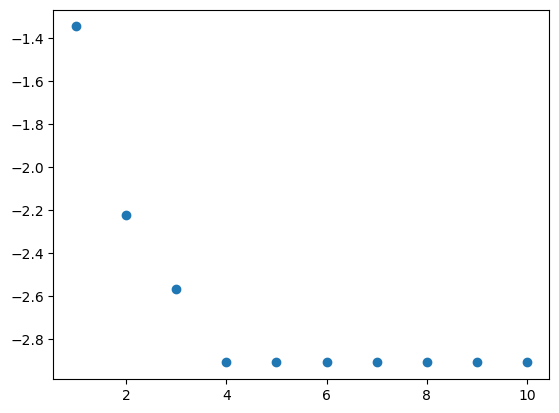

In [423]:
H=hamiltonien(2, liste, 2)
chi,e=variation_chi(10,2,2,H,10)

# Tracé du graphique avec chi en abscisse
plt.plot(chi, e, marker = "o",linestyle = "none")



# Afficher le graphique
plt.show()

In [440]:
liste=[[range(0, 8)], 2.25, 'I^8', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.5+0j), 'XZX'), ([0, 1, 2], (0.5+0j), 'YZY'), ([1, 2, 3], (0.5+0j), 'XZX'), ([1, 2, 3], (0.5+0j), 'YZY'), ([0, 1, 2, 3, 4], (0.5+0j), 'XZZZX'), ([0, 1, 2, 3, 4], (0.5+0j), 'YZZZY'), ([1, 2, 3, 4, 5], (0.5+0j), 'XZZZX'), ([1, 2, 3, 4, 5], (0.5+0j), 'YZZZY'), ([0, 1, 2, 3, 4, 5, 6], (0.5+0j), 'XZZZZZX'), ([0, 1, 2, 3, 4, 5, 6], (0.5+0j), 'YZZZZZY'), ([1, 2, 3, 4, 5, 6, 7], (0.5+0j), 'XZZZZZX'), ([1, 2, 3, 4, 5, 6, 7], (0.5+0j), 'YZZZZZY'), ([2], (-0.5+0j), 'Z'), ([3], (-0.5+0j), 'Z'), ([4], (-0.5+0j), 'Z'), ([5], (-0.5+0j), 'Z'), ([6], (-0.5+0j), 'Z'), ([7], (-0.5+0j), 'Z')]

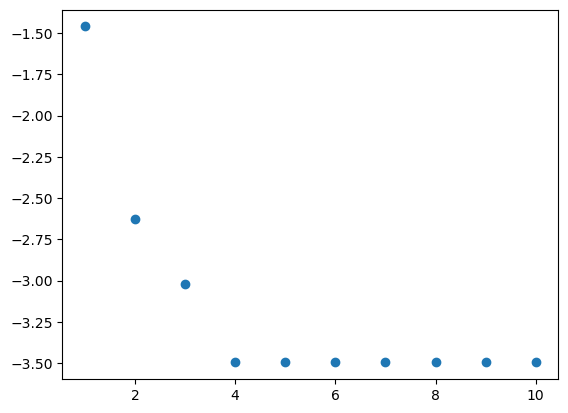

In [441]:
H=hamiltonien(3, liste, 2)
chi,e=variation_chi(10,3,2,H,10)

# Tracé du graphique avec chi en abscisse
plt.plot(chi, e, marker = "o",linestyle = "none")



# Afficher le graphique
plt.show()

In [442]:
print(e)

[-1.4599168816001131, -2.624318036447503, -3.021192615739044, -3.4957914753014623, -3.4957914753014596, -3.495791475301461, -3.4957914753014574, -3.4957914753014614, -3.495791475301461, -3.495791475301461]


Avec 5 sites de bain

In [426]:
liste=[[range(0, 12)], 4.25, 'I^12', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.5+0j), 'XZX'), ([0, 1, 2], (0.5+0j), 'YZY'), ([1, 2, 3], (0.5+0j), 'XZX'), ([1, 2, 3], (0.5+0j), 'YZY'), ([0, 1, 2, 3, 4], (0.5+0j), 'XZZZX'), ([0, 1, 2, 3, 4], (0.5+0j), 'YZZZY'), ([1, 2, 3, 4, 5], (0.5+0j), 'XZZZX'), ([1, 2, 3, 4, 5], (0.5+0j), 'YZZZY'), ([0, 1, 2, 3, 4, 5, 6], (0.5+0j), 'XZZZZZX'), ([0, 1, 2, 3, 4, 5, 6], (0.5+0j), 'YZZZZZY'), ([1, 2, 3, 4, 5, 6, 7], (0.5+0j), 'XZZZZZX'), ([1, 2, 3, 4, 5, 6, 7], (0.5+0j), 'YZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8], (0.5+0j), 'XZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8], (0.5+0j), 'YZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9], (0.5+0j), 'XZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9], (0.5+0j), 'YZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], (0.5+0j), 'XZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], (0.5+0j), 'YZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], (0.5+0j), 'XZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], (0.5+0j), 'YZZZZZZZZZY'), ([2], (-0.5+0j), 'Z'), ([3], (-0.5+0j), 'Z'), ([4], (-0.5+0j), 'Z'), ([5], (-0.5+0j), 'Z'), ([6], (-0.5+0j), 'Z'), ([7], (-0.5+0j), 'Z'), ([8], (-0.5+0j), 'Z'), ([9], (-0.5+0j), 'Z'), ([10], (-0.5+0j), 'Z'), ([11], (-0.5+0j), 'Z')]

In [427]:
H=hamiltonien(5,liste,2)
e,m=DMRG(10,12,2,4,H)

In [428]:
e[-1]

-4.449489742783179

In [429]:
e,m=DMRG(30,12,2,4,H)

In [430]:
e[-1]

-4.44948974278318

Avec 10 sites de bain

In [431]:
liste=[[range(0, 22)], 8.25, 'I^22', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.5+0j), 'XZX'), ([0, 1, 2], (0.5+0j), 'YZY'), ([1, 2, 3], (0.5+0j), 'XZX'), ([1, 2, 3], (0.5+0j), 'YZY'), ([0, 1, 2, 3, 4], (0.5+0j), 'XZZZX'), ([0, 1, 2, 3, 4], (0.5+0j), 'YZZZY'), ([1, 2, 3, 4, 5], (0.5+0j), 'XZZZX'), ([1, 2, 3, 4, 5], (0.5+0j), 'YZZZY'), ([0, 1, 2, 3, 4, 5, 6], (0.5+0j), 'XZZZZZX'), ([0, 1, 2, 3, 4, 5, 6], (0.5+0j), 'YZZZZZY'), ([1, 2, 3, 4, 5, 6, 7], (0.5+0j), 'XZZZZZX'), ([1, 2, 3, 4, 5, 6, 7], (0.5+0j), 'YZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8], (0.5+0j), 'XZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8], (0.5+0j), 'YZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9], (0.5+0j), 'XZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9], (0.5+0j), 'YZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], (0.5+0j), 'XZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], (0.5+0j), 'YZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], (0.5+0j), 'XZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], (0.5+0j), 'YZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], (0.5+0j), 'XZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], (0.5+0j), 'YZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], (0.5+0j), 'XZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], (0.5+0j), 'YZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], (0.5+0j), 'XZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], (0.5+0j), 'YZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], (0.5+0j), 'XZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], (0.5+0j), 'YZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], (0.5+0j), 'XZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], (0.5+0j), 'YZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], (0.5+0j), 'XZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], (0.5+0j), 'YZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], (0.5+0j), 'XZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], (0.5+0j), 'YZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], (0.5+0j), 'XZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], (0.5+0j), 'YZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], (0.5+0j), 'XZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], (0.5+0j), 'YZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], (0.5+0j), 'XZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], (0.5+0j), 'YZZZZZZZZZZZZZZZZZZZY'), ([2], (-0.5+0j), 'Z'), ([3], (-0.5+0j), 'Z'), ([4], (-0.5+0j), 'Z'), ([5], (-0.5+0j), 'Z'), ([6], (-0.5+0j), 'Z'), ([7], (-0.5+0j), 'Z'), ([8], (-0.5+0j), 'Z'), ([9], (-0.5+0j), 'Z'), ([10], (-0.5+0j), 'Z'), ([11], (-0.5+0j), 'Z'), ([12], (-0.5+0j), 'Z'), ([13], (-0.5+0j), 'Z'), ([14], (-0.5+0j), 'Z'), ([15], (-0.5+0j), 'Z'), ([16], (-0.5+0j), 'Z'), ([17], (-0.5+0j), 'Z'), ([18], (-0.5+0j), 'Z'), ([19], (-0.5+0j), 'Z'), ([20], (-0.5+0j), 'Z'), ([21], (-0.5+0j), 'Z')]

In [432]:
H=hamiltonien(10,liste,2)
e,m=DMRG(10,22,2,4,H)
e2,m2=DMRG(30,22,2,4,H)

In [433]:
e[-1],e2[-1]

(-7.241966939983719, -7.2419669399837225)

Avec 30 sites de bain

In [435]:
liste=[[range(0, 62)], 14.19655930918967, 'I^62', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.33704314577106087+0j), 'XZX'), ([0, 1, 2], (0.33704314577106087+0j), 'YZY'), ([1, 2, 3], (0.33704314577106087+0j), 'XZX'), ([1, 2, 3], (0.33704314577106087+0j), 'YZY'), ([0, 1, 2, 3, 4], (0.18334363013589072+0j), 'XZZZX'), ([0, 1, 2, 3, 4], (0.18334363013589072+0j), 'YZZZY'), ([1, 2, 3, 4, 5], (0.18334363013589072+0j), 'XZZZX'), ([1, 2, 3, 4, 5], (0.18334363013589072+0j), 'YZZZY'), ([0, 1, 2, 3, 4, 5, 6], (0.44525723578154514+0j), 'XZZZZZX'), ([0, 1, 2, 3, 4, 5, 6], (0.44525723578154514+0j), 'YZZZZZY'), ([1, 2, 3, 4, 5, 6, 7], (0.44525723578154514+0j), 'XZZZZZX'), ([1, 2, 3, 4, 5, 6, 7], (0.44525723578154514+0j), 'YZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8], (0.1632494908251556+0j), 'XZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8], (0.1632494908251556+0j), 'YZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9], (0.1632494908251556+0j), 'XZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9], (0.1632494908251556+0j), 'YZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], (0.4556561072887592+0j), 'XZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], (0.4556561072887592+0j), 'YZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], (0.4556561072887592+0j), 'XZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], (0.4556561072887592+0j), 'YZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], (0.15063923923522915+0j), 'XZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], (0.15063923923522915+0j), 'YZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], (0.15063923923522915+0j), 'XZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], (0.15063923923522915+0j), 'YZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], (0.07851732261466299+0j), 'XZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], (0.07851732261466299+0j), 'YZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], (0.07851732261466299+0j), 'XZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], (0.07851732261466299+0j), 'YZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], (0.4248189690426529+0j), 'XZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], (0.4248189690426529+0j), 'YZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], (0.4248189690426529+0j), 'XZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], (0.4248189690426529+0j), 'YZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], (0.2574111993664353+0j), 'XZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], (0.2574111993664353+0j), 'YZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], (0.2574111993664353+0j), 'XZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], (0.2574111993664353+0j), 'YZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], (0.3750379399662475+0j), 'XZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], (0.3750379399662475+0j), 'YZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], (0.3750379399662475+0j), 'XZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], (0.3750379399662475+0j), 'YZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], (0.15897912162250127+0j), 'XZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], (0.15897912162250127+0j), 'YZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], (0.15897912162250127+0j), 'XZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], (0.15897912162250127+0j), 'YZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], (0.1577583834751073+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], (0.1577583834751073+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25], (0.1577583834751073+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25], (0.1577583834751073+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26], (0.4580663369435633+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26], (0.4580663369435633+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27], (0.4580663369435633+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27], (0.4580663369435633+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28], (0.33350214395165706+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28], (0.33350214395165706+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], (0.33350214395165706+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], (0.33350214395165706+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30], (0.08116230560103815+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30], (0.08116230560103815+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], (0.08116230560103815+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], (0.08116230560103815+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], (0.38163431582418805+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], (0.38163431582418805+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], (0.38163431582418805+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], (0.38163431582418805+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34], (0.09660035299818459+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34], (0.09660035299818459+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35], (0.09660035299818459+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35], (0.09660035299818459+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36], (0.40010546892837845+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36], (0.40010546892837845+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], (0.40010546892837845+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], (0.40010546892837845+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38], (0.48574894837792876+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38], (0.48574894837792876+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39], (0.48574894837792876+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39], (0.48574894837792876+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40], (0.25654785874439107+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40], (0.25654785874439107+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], (0.25654785874439107+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], (0.25654785874439107+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42], (0.49742975320996685+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42], (0.49742975320996685+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], (0.49742975320996685+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], (0.49742975320996685+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44], (0.36431310677004114+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44], (0.36431310677004114+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45], (0.36431310677004114+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45], (0.36431310677004114+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46], (0.11545208012581515+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46], (0.11545208012581515+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47], (0.11545208012581515+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47], (0.11545208012581515+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48], (0.28495402180843443+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48], (0.28495402180843443+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], (0.28495402180843443+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], (0.28495402180843443+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50], (0.14909775678473752+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50], (0.14909775678473752+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51], (0.14909775678473752+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51], (0.14909775678473752+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52], (0.4012646256150709+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52], (0.4012646256150709+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53], (0.4012646256150709+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53], (0.4012646256150709+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54], (0.041966062647272484+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54], (0.041966062647272484+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55], (0.041966062647272484+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55], (0.041966062647272484+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56], (0.27668160304033984+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56], (0.27668160304033984+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57], (0.27668160304033984+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57], (0.27668160304033984+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58], (0.17885014976621827+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58], (0.17885014976621827+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], (0.17885014976621827+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], (0.17885014976621827+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60], (0.03207028210215468+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60], (0.03207028210215468+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61], (0.03207028210215468+0j), 'XZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZX'), ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61], (0.03207028210215468+0j), 'YZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZY'), ([2], (-0.06117667983910291+0j), 'Z'), ([3], (-0.06117667983910291+0j), 'Z'), ([4], (-0.23009915518149338+0j), 'Z'), ([5], (-0.23009915518149338+0j), 'Z'), ([6], (-0.49680577373045326+0j), 'Z'), ([7], (-0.49680577373045326+0j), 'Z'), ([8], (-0.3385735118160202+0j), 'Z'), ([9], (-0.3385735118160202+0j), 'Z'), ([10], (-0.2851887748701768+0j), 'Z'), ([11], (-0.2851887748701768+0j), 'Z'), ([12], (-0.3989071516148044+0j), 'Z'), ([13], (-0.3989071516148044+0j), 'Z'), ([14], (-0.01494450764629035+0j), 'Z'), ([15], (-0.01494450764629035+0j), 'Z'), ([16], (-0.07070228980118065+0j), 'Z'), ([17], (-0.07070228980118065+0j), 'Z'), ([18], (-0.43910803007163546+0j), 'Z'), ([19], (-0.43910803007163546+0j), 'Z'), ([20], (-0.03760263517196366+0j), 'Z'), ([21], (-0.03760263517196366+0j), 'Z'), ([22], (-0.4908806717952075+0j), 'Z'), ([23], (-0.4908806717952075+0j), 'Z'), ([24], (-0.24091307938418843+0j), 'Z'), ([25], (-0.24091307938418843+0j), 'Z'), ([26], (-0.21059551229923534+0j), 'Z'), ([27], (-0.21059551229923534+0j), 'Z'), ([28], (-0.15615212958321983+0j), 'Z'), ([29], (-0.15615212958321983+0j), 'Z'), ([30], (-0.4960132752979086+0j), 'Z'), ([31], (-0.4960132752979086+0j), 'Z'), ([32], (-0.08519687703990525+0j), 'Z'), ([33], (-0.08519687703990525+0j), 'Z'), ([34], (-0.1432593846300284+0j), 'Z'), ([35], (-0.1432593846300284+0j), 'Z'), ([36], (-0.14706656343969088+0j), 'Z'), ([37], (-0.14706656343969088+0j), 'Z'), ([38], (-0.3543816440967371+0j), 'Z'), ([39], (-0.3543816440967371+0j), 'Z'), ([40], (-0.28889381989123997+0j), 'Z'), ([41], (-0.28889381989123997+0j), 'Z'), ([42], (-0.28593271225414807+0j), 'Z'), ([43], (-0.28593271225414807+0j), 'Z'), ([44], (-0.043494114927609906+0j), 'Z'), ([45], (-0.043494114927609906+0j), 'Z'), ([46], (-0.16939140833707922+0j), 'Z'), ([47], (-0.16939140833707922+0j), 'Z'), ([48], (-0.28531816790891623+0j), 'Z'), ([49], (-0.28531816790891623+0j), 'Z'), ([50], (-0.43878234149411716+0j), 'Z'), ([51], (-0.43878234149411716+0j), 'Z'), ([52], (-0.3944131777805889+0j), 'Z'), ([53], (-0.3944131777805889+0j), 'Z'), ([54], (-0.39480143511377647+0j), 'Z'), ([55], (-0.39480143511377647+0j), 'Z'), ([56], (-0.20070268440878508+0j), 'Z'), ([57], (-0.20070268440878508+0j), 'Z'), ([58], (-0.2668384676316419+0j), 'Z'), ([59], (-0.2668384676316419+0j), 'Z'), ([60], (-0.007143677537690296+0j), 'Z'), ([61], (-0.007143677537690296+0j), 'Z')]

In [436]:
H=hamiltonien(30,liste,2)
e,m=DMRG(10,62,2,4,H)

In [437]:
e[-1]

-7.005215443493862

In [446]:
def variation_Np(Np_max,nb,d,H,chi):
    """
    Np, d, H comme dans DMRG
    On prend nb le nombre de sites de bain
    On fera varier chi de 1 à chi_max
    """
    Np=[i for i in range(1,Np_max+1)]
    e=[0 for i in range(1,Np_max+1)]
    for i in range(1,Np_max+1):
        E,A=DMRG(i,2*(nb+1),d,chi,H)
        e[i-1]=E[-1]
    return Np, e  

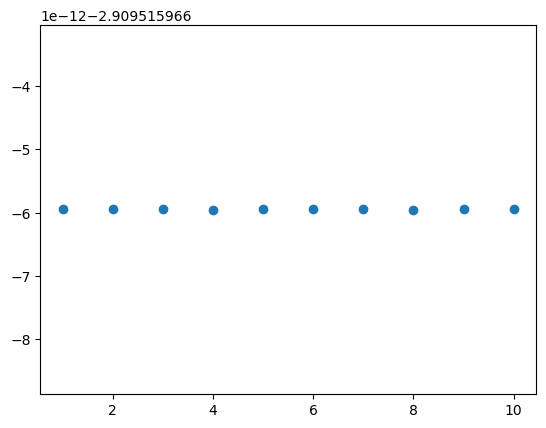

In [447]:
liste=[[range(0, 6)], 1.25, 'I^6', ([0, 1], (0.25+0j), 'ZZ'), ([0], (0.25+0j), 'Z'), ([1], (0.25+0j), 'Z'), ([0, 1, 2], (0.5+0j), 'XZX'), ([0, 1, 2], (0.5+0j), 'YZY'), ([1, 2, 3], (0.5+0j), 'XZX'), ([1, 2, 3], (0.5+0j), 'YZY'), ([0, 1, 2, 3, 4], (0.5+0j), 'XZZZX'), ([0, 1, 2, 3, 4], (0.5+0j), 'YZZZY'), ([1, 2, 3, 4, 5], (0.5+0j), 'XZZZX'), ([1, 2, 3, 4, 5], (0.5+0j), 'YZZZY'), ([2], (-0.5+0j), 'Z'), ([3], (-0.5+0j), 'Z'), ([4], (-0.5+0j), 'Z'), ([5], (-0.5+0j), 'Z')]
H=hamiltonien(2, liste, 2)
Np,e=variation_Np(10,2,2,H,10)

# Tracé du graphique avec chi en abscisse
plt.plot(Np, e, marker = "o",linestyle = "none")



# Afficher le graphique
plt.show()